<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/02.circuits-and-encoding/02.feature-encoding/32_measurement_probability_oscillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day18 measurement probability oscillation 실습

- Source: Google Drive `Day18/4-4.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Frequency
Frequency : 5 Hz


STEP 2. Time
Time Sample : 30


STEP 3. Measurement


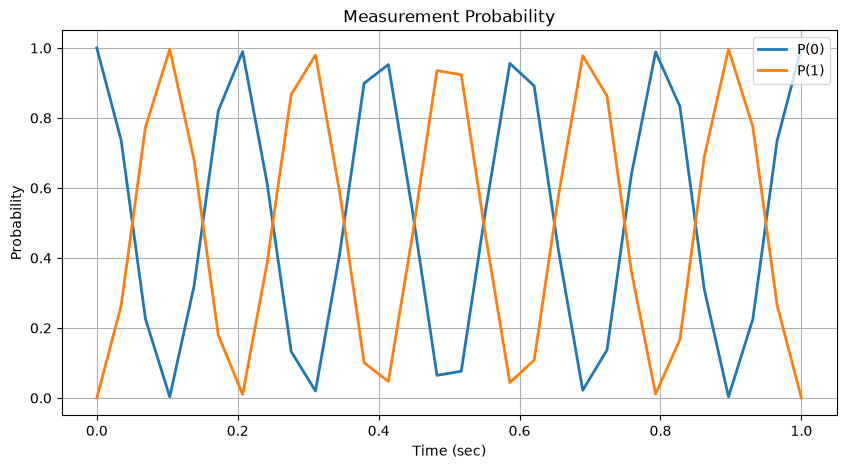

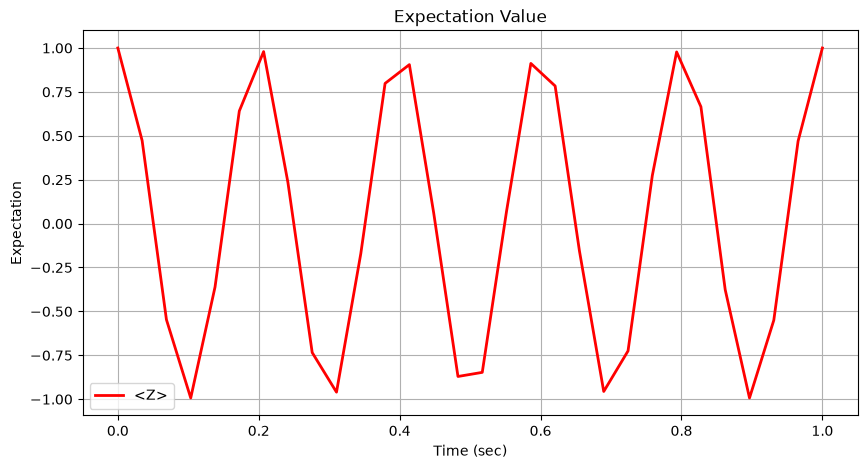



Summary
 Time    P(0)    P(1)    <Z>
 0.00    1.000    0.000    1.000
 0.03    0.736    0.264    0.473
 0.07    0.227    0.773   -0.547
 0.10    0.003    0.997   -0.993
 0.14    0.319    0.681   -0.361
 0.17    0.821    0.179    0.641
 0.21    0.990    0.010    0.979
 0.24    0.617    0.383    0.235
 0.28    0.133    0.867   -0.734
 0.31    0.020    0.980   -0.960
 0.34    0.414    0.586   -0.171
 0.38    0.899    0.101    0.798
 0.41    0.953    0.047    0.905
 0.45    0.531    0.469    0.062
 0.48    0.065    0.935   -0.871
 0.52    0.076    0.924   -0.847
 0.55    0.535    0.465    0.071
 0.59    0.956    0.044    0.912
 0.62    0.892    0.108    0.784
 0.66    0.422    0.578   -0.156
 0.69    0.022    0.978   -0.956
 0.72    0.137    0.863   -0.725
 0.76    0.637    0.363    0.274
 0.79    0.989    0.011    0.978
 0.83    0.833    0.167    0.666
 0.86    0.312    0.688   -0.376
 0.90    0.003    0.997   -0.993
 0.93    0.225    0.775   -0.550
 0.97    0.735    0.265    0.470
 1.0

In [1]:
"""
==========================================================
Lab 6-3
Measurement Probability 변화 비교
==========================================================

목적
- Time Evolution에 따른 Measurement 변화 확인
- Probability Oscillation 분석
- Expectation Value 계산
"""

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

# =====================================================
# STEP 1
# Frequency 설정
# =====================================================

print("=" * 60)
print("STEP 1. Frequency")
print("=" * 60)

frequency = 5

print(f"Frequency : {frequency} Hz")

# =====================================================
# STEP 2
# Time Axis
# =====================================================

print("\n")
print("=" * 60)
print("STEP 2. Time")
print("=" * 60)

time_list = np.linspace(
    0,
    1,
    30
)

print(f"Time Sample : {len(time_list)}")

# =====================================================
# STEP 3
# Simulator
# =====================================================

backend = AerSimulator()

p0_list = []
p1_list = []
expectation_list = []

# =====================================================
# STEP 4
# Measurement
# =====================================================

print("\n")
print("=" * 60)
print("STEP 3. Measurement")
print("=" * 60)

for t in time_list:

    theta = 2 * np.pi * frequency * t

    qc = QuantumCircuit(1)

    qc.ry(theta,0)

    qc.measure_all()

    tqc = transpile(
        qc,
        backend
    )

    job = backend.run(
        tqc,
        shots=4096
    )

    result = job.result()

    counts = result.get_counts()

    shots = sum(counts.values())

    p0 = counts.get("0",0)/shots
    p1 = counts.get("1",0)/shots

    expectation = p0-p1

    p0_list.append(p0)
    p1_list.append(p1)
    expectation_list.append(expectation)

# =====================================================
# STEP 5
# Probability Graph
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    time_list,
    p0_list,
    label="P(0)",
    linewidth=2
)

plt.plot(
    time_list,
    p1_list,
    label="P(1)",
    linewidth=2
)

plt.xlabel("Time (sec)")

plt.ylabel("Probability")

plt.title("Measurement Probability")

plt.grid(True)

plt.legend()

plt.show()

# =====================================================
# STEP 6
# Expectation Graph
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    time_list,
    expectation_list,
    color="red",
    linewidth=2,
    label="<Z>"
)

plt.xlabel("Time (sec)")

plt.ylabel("Expectation")

plt.title("Expectation Value")

plt.grid(True)

plt.legend()

plt.show()

# =====================================================
# STEP 7
# Summary
# =====================================================

print("\n")
print("=" * 60)
print("Summary")
print("=" * 60)

print(" Time    P(0)    P(1)    <Z>")

for t,p0,p1,e in zip(
    time_list,
    p0_list,
    p1_list,
    expectation_list
):

    print(
        f"{t:5.2f}   "
        f"{p0:6.3f}   "
        f"{p1:6.3f}   "
        f"{e:6.3f}"
    )

print("\n실습 완료")
